# Organización del Código

Este cuaderno se ha organizado en diferentes secciones para mejorar su legibilidad y comprensión. Cada sección contiene celdas de código y texto explicativo para guiar a través del proceso de carga de datos, entrenamiento y evaluación de modelos de clasificación de imágenes utilizando PyTorch.

## 1. Configuración e Importaciones

Esta sección importa las librerías necesarias para el proyecto, configura el dispositivo (CPU o GPU) y crea los directorios donde se guardarán los resultados y los modelos entrenados.

In [1]:
# Importar librerías
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import KFold
from tqdm import tqdm
import os

# Configurar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


# Crear los directorios 'resultados' y 'modelos' si no existen
if not os.path.exists('resultados'):
    os.makedirs('resultados')
    print("Directorio 'resultados' creado.")
else:
    print("Directorio 'resultados' ya existe.")

if not os.path.exists('modelos'):
    os.makedirs('modelos')
    print("Directorio 'modelos' creado.")
else:
    print("Directorio 'modelos' ya existe.")

Usando dispositivo: cpu
Directorio 'resultados' creado.
Directorio 'modelos' creado.


## 2. Cargar y Visualizar el Dataset

Aquí se carga el dataset MNIST, que es un conjunto de datos de dígitos escritos a mano comúnmente utilizado para tareas de clasificación de imágenes. También se aplica una transformación básica a las imágenes y se visualiza un ejemplo.

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.14MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.51MB/s]


Tamaño del set de entrenamiento: 60000
Tamaño del set de prueba: 10000


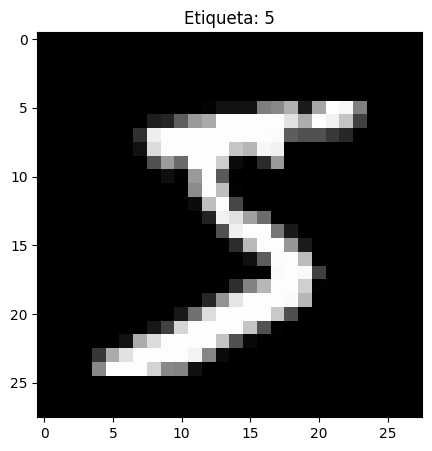

In [2]:
# Cargar y visualizar el dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)

print("Tamaño del set de entrenamiento:", len(train_data))
print("Tamaño del set de prueba:", len(test_data))

# Visualizar ejemplo
image, label = train_data[0]
plt.figure(figsize=(5, 5))
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Etiqueta: {label}")
plt.savefig("resultados/ejemplo_imagen.png")
plt.show()

## 3. Preparar los Dataloaders

En esta sección, el conjunto de entrenamiento se divide en conjuntos de entrenamiento y validación. Luego, se crean los `DataLoader` para iterar sobre los datos en lotes durante el entrenamiento y la evaluación.

In [3]:
# Preparar los dataloaders
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

print(f"Tamaño del set de entrenamiento (split): {len(train_subset)}")
print(f"Tamaño del set de validación: {len(val_subset)}")
print(f"Tamaño del set de prueba: {len(test_data)}")
print(f"Tamaño del lote: {batch_size}")

Tamaño del set de entrenamiento (split): 48000
Tamaño del set de validación: 12000
Tamaño del set de prueba: 10000
Tamaño del lote: 64


## 4. Definir y Entrenar el Modelo Simple

Aquí se define una red neuronal simple (`SimpleNet`) con capas completamente conectadas. Se configura la función de pérdida (entropía cruzada) y el optimizador (Adam). Finalmente, se entrena el modelo durante un número especificado de épocas, realizando también la validación en cada época.

In [4]:
# Definir el modelo
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu1 = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.dropout(x)
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

model = SimpleNet().to(device)
print("Modelo SimpleNet definido.")

# Configurar función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("Función de pérdida y optimizador configurados.")

# Entrenar el modelo
epochs = 10
train_losses, val_losses, val_accuracies = [], [], []

print(f"\nComenzando entrenamiento del modelo SimpleNet por {epochs} épocas...")
for epoch in tqdm(range(epochs), desc="Entrenamiento SimpleNet"):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # Validación
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            val_loss += criterion(output, labels).item()
            _, predicted = torch.max(output.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    accuracy = correct / total
    val_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Accuracy: {accuracy:.4f}")

print("\nEntrenamiento del modelo SimpleNet finalizado.")

Modelo SimpleNet definido.
Función de pérdida y optimizador configurados.

Comenzando entrenamiento del modelo SimpleNet por 10 épocas...


Entrenamiento SimpleNet:  10%|█         | 1/10 [00:12<01:55, 12.80s/it]

Epoch 1/10, Train Loss: 0.4642, Val Loss: 0.2452, Val Accuracy: 0.9240


Entrenamiento SimpleNet:  20%|██        | 2/10 [00:25<01:41, 12.69s/it]

Epoch 2/10, Train Loss: 0.2336, Val Loss: 0.1620, Val Accuracy: 0.9492


...

Epoch 8/10, Train Loss: 0.1171, Val Loss: 0.1325, Val Accuracy: 0.9600


Entrenamiento SimpleNet:  90%|█████████ | 9/10 [01:58<00:13, 13.39s/it]

Epoch 9/10, Train Loss: 0.1063, Val Loss: 0.1239, Val Accuracy: 0.9637


Entrenamiento SimpleNet: 100%|██████████| 10/10 [02:11<00:00, 13.15s/it]

Epoch 10/10, Train Loss: 0.1029, Val Loss: 0.1241, Val Accuracy: 0.9622

Entrenamiento del modelo SimpleNet finalizado.


## 5. Evaluar el Modelo Simple

En esta sección, se evalúa el rendimiento final del `SimpleNet` en el conjunto de prueba. Se genera un reporte de clasificación con métricas como precisión, recall y F1-score, y se visualiza la matriz de confusión para entender cómo el modelo clasifica cada clase. También se visualizan las curvas de pérdida de entrenamiento y validación.

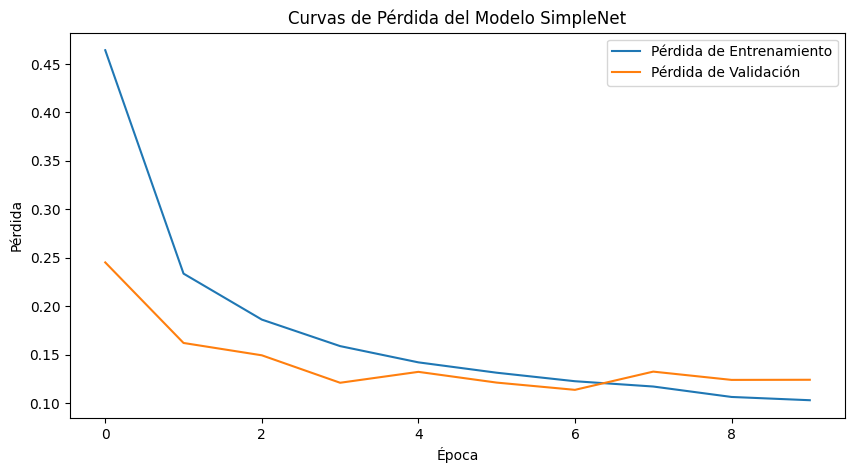


Evaluando SimpleNet en el conjunto de prueba...

Reporte de Clasificación en Test (SimpleNet):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.95      0.97      1032
           3       0.95      0.98      0.96      1010
           4       0.95      0.97      0.96       982
           5       0.96      0.97      0.97       892
           6       0.98      0.96      0.97       958
           7       0.92      0.99      0.95      1028
           8       0.98      0.94      0.96       974
           9       0.98      0.90      0.94      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



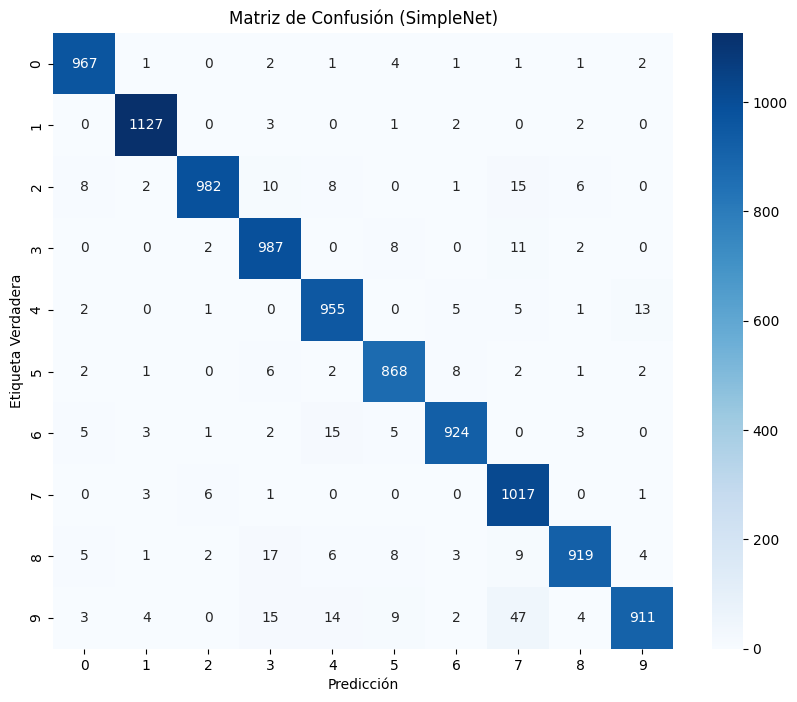

Evaluación del modelo SimpleNet finalizada.


In [5]:
# Visualizar curvas de pérdida
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Pérdida de Entrenamiento')
plt.plot(val_losses, label='Pérdida de Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Curvas de Pérdida del Modelo SimpleNet')
plt.legend()
plt.savefig("resultados/curva_loss_simplenet.png")
plt.show()

# Evaluación en test
model.eval()
all_preds, all_labels = [], []

print("\nEvaluando SimpleNet en el conjunto de prueba...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        output = model(images)
        _, preds = torch.max(output, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Reporte de clasificación
print("\nReporte de Clasificación en Test (SimpleNet):")
print(classification_report(all_labels, all_preds))

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión (SimpleNet)')
plt.savefig("resultados/confusion_matrix_simplenet.png")
plt.show()
print("Evaluación del modelo SimpleNet finalizada.")

## 6. Validación Cruzada (K-Fold)

Para obtener una evaluación más robusta del rendimiento del `SimpleNet` y reducir la dependencia de una única división entrenamiento/validación, se realiza validación cruzada de K-Fold (con K=5). Se entrena y evalúa el modelo en diferentes subconjuntos de los datos de entrenamiento.

In [6]:
# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
X = torch.stack([train_data[i][0] for i in range(len(train_data))])
y = torch.tensor([train_data[i][1] for i in range(len(train_data))])
kfold_accuracies = []

print("\nComenzando Validación Cruzada (K-Fold) para SimpleNet...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\nFold {fold+1}/5")
    train_subsampler = torch.utils.data.SubsetRandomSampler(train_idx)
    val_subsampler = torch.utils.data.SubsetRandomSampler(val_idx)

    train_loader_kf = DataLoader(train_data, batch_size=batch_size, sampler=train_subsampler)
    val_loader_kf = DataLoader(train_data, batch_size=batch_size, sampler=val_subsampler)

    model_kf = SimpleNet().to(device)
    optimizer_kf = optim.Adam(model_kf.parameters(), lr=0.001)

    # Entrenar por menos épocas en K-Fold para ahorrar tiempo
    for epoch in range(3):
        model_kf.train()
        for images, labels in train_loader_kf:
            images, labels = images.to(device), labels.to(device)
            optimizer_kf.zero_grad()
            output = model_kf(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer_kf.step()

    model_kf.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader_kf:
            images, labels = images.to(device), labels.to(device)
            output = model_kf(images)
            _, predicted = torch.max(output.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    kfold_accuracies.append(accuracy)
    print(f"Fold {fold+1} Accuracy: {accuracy:.4f}")

print(f"\nK-Fold Mean Accuracy (SimpleNet): {np.mean(kfold_accuracies):.4f} ± {np.std(kfold_accuracies):.4f}")
print("Validación Cruzada (K-Fold) finalizada.")


Comenzando Validación Cruzada (K-Fold) para SimpleNet...

Fold 1/5
Fold 1 Accuracy: 0.9558

Fold 2/5
Fold 2 Accuracy: 0.9503

Fold 3/5
Fold 3 Accuracy: 0.9556

Fold 4/5
Fold 4 Accuracy: 0.9539

Fold 5/5
Fold 5 Accuracy: 0.9497

K-Fold Mean Accuracy (SimpleNet): 0.9530 ± 0.0026
Validación Cruzada (K-Fold) finalizada.


## 7. Fine-Tuning con Modelo Preentrenado (ResNet18)

Aunque MNIST es un dataset simple y no ideal para modelos preentrenados en ImageNet (que espera imágenes a color con 3 canales), esta sección demuestra cómo adaptar y usar un modelo ResNet18 preentrenado.

Primero, se modifica la primera capa convolucional para aceptar imágenes con 1 canal (escala de grises). Luego, se entrena solo la capa final (clasificador) mientras se congelan los pesos del resto del modelo. Finalmente, se realiza fine-tuning completo, descongelando algunas o todas las capas y entrenando con una tasa de aprendizaje más baja.

In [ ]:
# Fine-Tuning con modelo preentrenado
# Nota: MNIST no es ideal para ResNet18 preentrenado en ImageNet, pero adaptamos
print("\nComenzando Fine-Tuning con ResNet18...")

model_ft = models.resnet18(pretrained=True)

# Modificar capa convolucional inicial para 1 canal (MNIST)
model_ft.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Congelar todas las capas excepto la final
for param in model_ft.parameters():
    param.requires_grad = False

# Modificar la capa final (clasificador)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 10)
model_ft.to(device)
print("Modelo ResNet18 adaptado y enviado al dispositivo.")

# Entrenar solo la capa final
optimizer_ft = optim.Adam(model_ft.fc.parameters(), lr=1e-4)
train_losses_ft, val_losses_ft, val_accuracies_ft = [], [], []

print("\nEntrenando solo la capa final del ResNet18...")
for epoch in tqdm(range(5), desc="Fine-Tuning (Capa Final)"):
    model_ft.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_ft.zero_grad()
        output = model_ft(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer_ft.step()
        running_loss += loss.item()

    train_losses_ft.append(running_loss / len(train_loader))

    model_ft.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            output = model_ft(images)
            val_loss += criterion(output, labels).item()
            _, predicted = torch.max(output.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses_ft.append(val_loss / len(val_loader))
    accuracy = correct / total
    val_accuracies_ft.append(accuracy)

    print(f"Epoch {epoch+1}/5, Train Loss: {train_losses_ft[-1]:.4f}, Val Loss: {val_losses_ft[-1]:.4f}, Val Accuracy: {accuracy:.4f}")

print("\nEntrenamiento de la capa final de ResNet18 finalizado.")

# Fine-tuning completo
print("\nComenzando Fine-Tuning completo del ResNet18...")
for param in model_ft.parameters():
    param.requires_grad = True
optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-5) # Tasa de aprendizaje más baja
train_losses_ft_full, val_losses_ft_full, val_accuracies_ft_full = [], [], []

for epoch in tqdm(range(5), desc="Fine-Tuning (Completo)"):
    model_ft.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_ft.zero_grad()
        output = model_ft(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer_ft.step()
        running_loss += loss.item()

    train_losses_ft_full.append(running_loss / len(train_loader))

    model_ft.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            output = model_ft(images)
            val_loss += criterion(output, labels).item()
            _, predicted = torch.max(output.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses_ft_full.append(val_loss / len(val_loader))
    accuracy = correct / total
    val_accuracies_ft_full.append(accuracy)

    print(f"Epoch {epoch+1}/5, Train Loss: {train_losses_ft_full[-1]:.4f}, Val Loss: {val_losses_ft_full[-1]:.4f}, Val Accuracy: {accuracy:.4f}")

print("\nFine-Tuning completo de ResNet18 finalizado.")


Comenzando Fine-Tuning con ResNet18...


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s]


Modelo ResNet18 adaptado y enviado al dispositivo.

Entrenando solo la capa final del ResNet18...


Fine-Tuning (Capa Final):  20%|██        | 1/5 [02:10<08:41, 130.47s/it]

Epoch 1/5, Train Loss: 1.8650, Val Loss: 1.5745, Val Accuracy: 0.4878


...

Epoch 3/5, Train Loss: 0.2153, Val Loss: 0.1917, Val Accuracy: 0.9416


Fine-Tuning (Completo):  80%|████████  | 4/5 [32:15<08:01, 481.73s/it]

Epoch 4/5, Train Loss: 0.1529, Val Loss: 0.1565, Val Accuracy: 0.9515


Fine-Tuning (Completo): 100%|██████████| 5/5 [40:29<00:00, 485.84s/it]

Epoch 5/5, Train Loss: 0.1179, Val Loss: 0.1381, Val Accuracy: 0.9577

Fine-Tuning completo de ResNet18 finalizado.


## 8. Comparación de Modelos

Esta sección compara las precisiones de validación de los modelos entrenados (`SimpleNet`, `ResNet18` con solo la capa final entrenada, y `ResNet18` con fine-tuning completo) y guarda los resultados en un archivo CSV. También se visualiza esta comparación en un gráfico de barras.


Comparando métricas de los modelos...
Métricas guardadas en 'resultados/comparacion_metrics.csv'


,Modelo,Val Accuracy
0,SimpleNet,0.962167
1,ResNet18 (Capa Final),0.576667
2,ResNet18 (Fine-Tuning Completo),0.957750


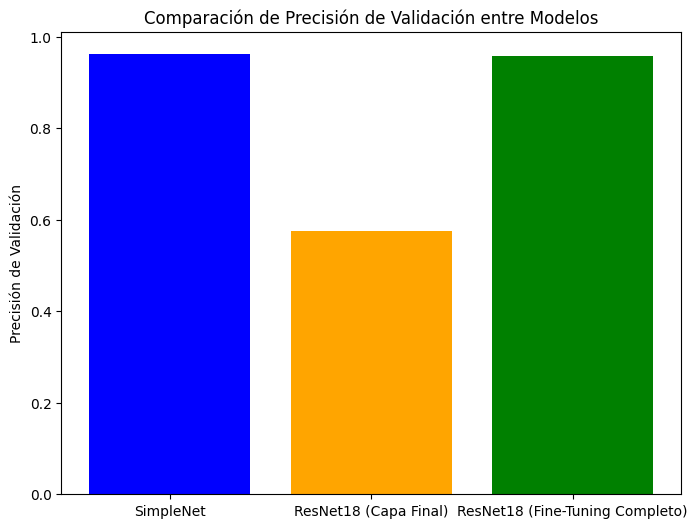

Gráfico de comparación de modelos guardado en 'resultados/comparacion_modelos.png'


In [ ]:
# Comparación de métricas
print("\nComparando métricas de los modelos...")
metrics_df = pd.DataFrame({
    'Modelo': ['SimpleNet', 'ResNet18 (Capa Final)', 'ResNet18 (Fine-Tuning Completo)'],
    'Val Accuracy': [val_accuracies[-1], val_accuracies_ft[-1], val_accuracies_ft_full[-1]]
})
metrics_df.to_csv("resultados/comparacion_metrics.csv", index=False)
print("Métricas guardadas en 'resultados/comparacion_metrics.csv'")
display(metrics_df)

# Visualización de comparación
plt.figure(figsize=(8, 6))
plt.bar(metrics_df['Modelo'], metrics_df['Val Accuracy'], color=['blue', 'orange', 'green'])
plt.ylabel('Precisión de Validación')
plt.title('Comparación de Precisión de Validación entre Modelos')
plt.savefig("resultados/comparacion_modelos.png")
plt.show()
print("Gráfico de comparación de modelos guardado en 'resultados/comparacion_modelos.png'")

## 9. Guardar y Cargar el Modelo Final

Finalmente, se guarda el estado del modelo ResNet18 con fine-tuning completo, que probablemente tenga el mejor rendimiento. Luego se carga el estado del modelo guardado para verificar que se haya guardado correctamente.

In [ ]:
# Guardar el modelo
print("\nGuardando el modelo final...")
torch.save(model_ft.state_dict(), "modelos/modelo_final.pth")
print("Modelo final guardado en 'modelos/modelo_final.pth'")

# Cargar y verificar
print("Cargando el modelo guardado para verificación...")
model_ft_loaded = models.resnet18(pretrained=False) # Crear una instancia vacía del modelo
model_ft_loaded.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
num_ftrs_loaded = model_ft_loaded.fc.in_features
model_ft_loaded.fc = nn.Linear(num_ftrs_loaded, 10)
model_ft_loaded.load_state_dict(torch.load("modelos/modelo_final.pth"))
model_ft_loaded.eval()
model_ft_loaded.to(device)
print("Modelo cargado correctamente.")

# Opcional: Evaluar el modelo cargado en el conjunto de prueba para verificar
# print("\nEvaluando el modelo cargado en el conjunto de prueba...")
# all_preds_loaded, all_labels_loaded = [], []
# with torch.no_grad():
#     for images, labels in test_loader:
#         images = images.to(device)
#         output = model_ft_loaded(images)
#         _, preds = torch.max(output, 1)
#         all_preds_loaded.extend(preds.cpu().numpy())
#         all_labels_loaded.extend(labels.numpy())
#
# print("\nReporte de Clasificación en Test (Modelo Cargado):")
# print(classification_report(all_labels_loaded, all_preds_loaded))


Guardando el modelo final...
Modelo final guardado en 'modelos/modelo_final.pth'
Cargando el modelo guardado para verificación...
Modelo cargado correctamente.


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
